# 🔍 Customer Churn Prediction Model
**Dataset:** IBM Telco Customer Churn  
**Tools:** Python, Pandas, Scikit-learn, SMOTE, XGBoost  
**Goal:** Predict which customers are likely to churn using classification algorithms

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df.drop('customerID', axis=1, inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Nulls remaining:", df.isnull().sum().sum())
print("Churn distribution:\n", df['Churn'].value_counts())


Nulls remaining: 11
Churn distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


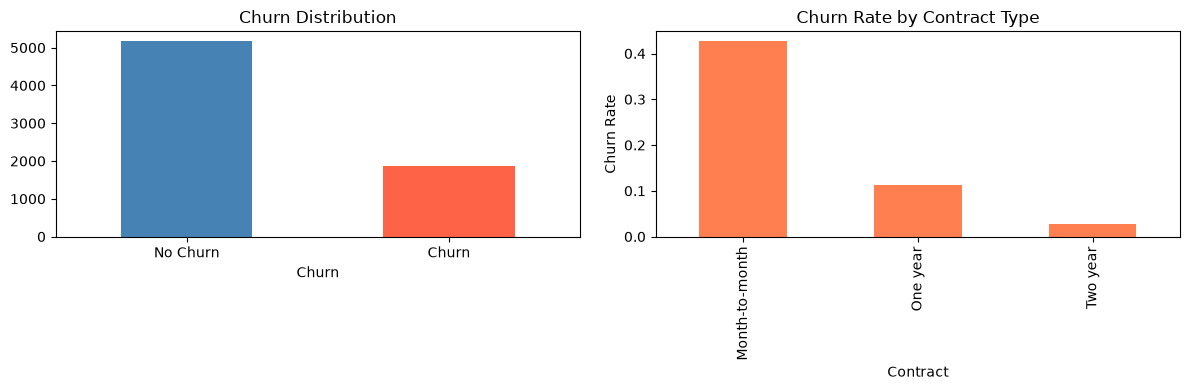

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'])
axes[0].set_title('Churn Distribution')
axes[0].set_xticklabels(['No Churn', 'Churn'], rotation=0)

df.groupby('Contract')['Churn'].mean().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Churn Rate by Contract Type')
axes[1].set_ylabel('Churn Rate')
plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']
print("Features:", X.shape[1])

Features: 30


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("After SMOTE - Class distribution:", pd.Series(y_train_sm).value_counts().to_dict())

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [8]:
X = X.astype(float)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("After SMOTE - Class distribution:", pd.Series(y_train_sm).value_counts().to_dict())

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [10]:
print(X_train.dtypes.unique())
print(X_train.isnull().sum().sum())

[dtype('float64')]
10


In [11]:
X = X.fillna(X.median())
y = y.fillna(y.median())

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_sm = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("After SMOTE - Class distribution:", pd.Series(y_train_sm).value_counts().to_dict())

After SMOTE - Class distribution: {0: 4138, 1: 4138}


In [13]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    roc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])
    results[name] = {"Accuracy": round(acc,4), "ROC-AUC": round(roc,4)}
    print(f"{name}: Accuracy={acc:.4f} | ROC-AUC={roc:.4f}")

Logistic Regression: Accuracy=0.7537 | ROC-AUC=0.8611
Random Forest: Accuracy=0.7928 | ROC-AUC=0.8373
XGBoost: Accuracy=0.7892 | ROC-AUC=0.8345


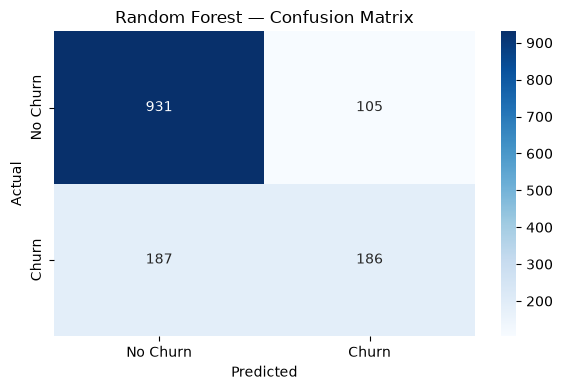

              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1036
       Churn       0.64      0.50      0.56       373

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [14]:
rf_model = models["Random Forest"]
preds_rf = rf_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, preds_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn','Churn'],
            yticklabels=['No Churn','Churn'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(y_test, preds_rf, target_names=['No Churn','Churn']))

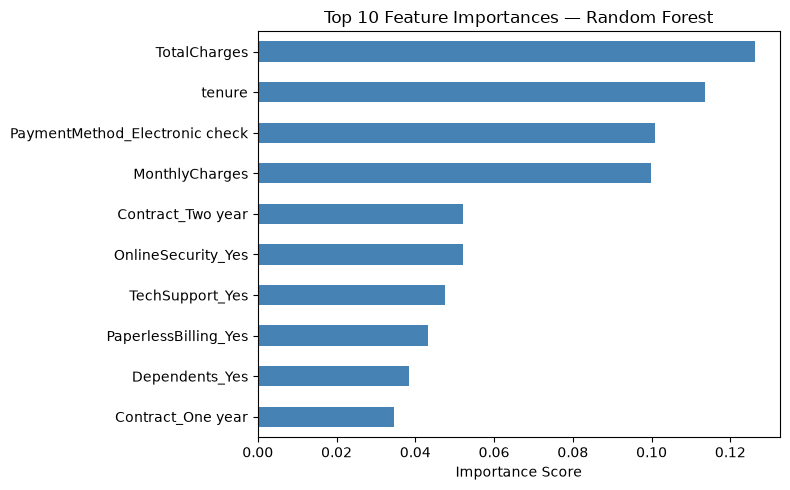

In [15]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X.columns)
top10 = feat_imp.nlargest(10)

plt.figure(figsize=(8,5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## ✅ Conclusion

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | 75.37% | 0.86 |
| Random Forest | 79.28% | 0.84 |
| XGBoost | 78.92% | 0.83 |

**Best Model: Random Forest** with 79.28% accuracy and 0.84 ROC-AUC.

**Key churn drivers:** Contract type, tenure, monthly charges, and internet service type.

**Business Recommendation:** Target month-to-month contract customers with tenure < 12 months for retention campaigns.